# **Regression Trees**


In this notebook we will use a real dataset to train a regression tree model. The dataset includes information about taxi tip and was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers authorized under the Taxicab & Livery Passenger Enhancement Programs (TPEP/LPEP). We will use the trained model to predict the amount of tip paid. 

## Objectives
* Perform basic data preprocessing using Scikit-Learn
* Model a regression task using Scikit-Learn
* Train a Decision Tree Regressor model
* Run inference and assess the quality of the trained models

<div id="import_libraries">
    <h2>Import Libraries</h2>
</div>


In [2]:
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install scikit-learn

In [3]:
from __future__ import print_function
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings('ignore')

<div id="dataset_analysis">
    <h2>Dataset Analysis</h2>
</div>


In this section you will read the dataset in a Pandas dataframe and visualize its content. We will also look at some data statistics.

Note: A Pandas dataframe is a two-dimensional, size-mutable, potentially heterogeneous tabular data structure.


In [4]:
# read the input data
url = 'datasets/test_2015.csv'
raw_data = pd.read_csv(url)
raw_data

,RateCodeID,RatecodeID,VendorID,dropoff_latitude,dropoff_longitude,extra,fare_amount,improvement_surcharge,mta_tax,passenger_count,payment_type,pickup_latitude,pickup_longitude,store_and_fwd_flag,tip_amount,tolls_amount,total_amount,tpep_dropoff_datetime,tpep_pickup_datetime,trip_distance
0,1.0,NaN,1,40.782337,-73.972160,0.0,5.0,0.3,0.5,1,2,40.789295,-73.966629,N,0.00,0.00,5.80,2015-01-09 12:58:40,2015-01-09 12:54:55,0.50
1,1.0,NaN,1,40.720490,-73.945465,0.5,12.5,0.3,0.5,1,1,40.723850,-73.992561,N,2.00,0.00,15.80,2015-01-13 23:19:17,2015-01-13 23:09:04,3.60
2,1.0,NaN,1,40.721367,-73.994781,0.0,14.5,0.3,0.5,2,2,40.749100,-73.991959,N,0.00,0.00,15.30,2015-01-25 17:37:55,2015-01-25 17:17:28,2.30
3,1.0,NaN,1,0.000000,0.000000,1.0,4.0,0.3,0.5,1,1,0.000000,0.000000,N,1.00,0.00,6.80,2015-01-22 19:00:38,2015-01-22 18:57:09,0.40
4,1.0,NaN,2,40.737110,-73.998177,0.0,4.5,0.3,0.5,1,1,40.733742,-73.990379,N,1.70,0.00,7.00,2015-01-17 18:16:01,2015-01-17 18:11:48,0.48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1446512,NaN,1.0,1,40.762688,-73.982063,0.0,9.5,0.3,0.5,1,1,40.790752,-73.968971,N,2.55,0.00,12.85,2015-12-28 11:41:19,2015-12-28 11:30:23,2.20
1446513,NaN,1.0,1,40.785164,-73.951553,0.0,6.5,0.3,0.5,1,1,40.771503,-73.950569,N,1.00,0.00,8.30,2015-12-15 12:42:41,2015-12-15 12:36:50,1.30
1446514,NaN,1.0,1,40.805920,-73.961578,0.0,8.0,0.3,0.5,1,1,40.795319,-73.965858,N,0.00,0.00,8.80,2015-12-03 10:25:39,2015-12-03 10:16:14,1.20
1446515,NaN,1.0,2,40.747234,-73.916939,0.0,27.0,0.3,0.5,1,1,40.754704,-73.992554,N,6.67,5.54,40.01,2015-12-05 15:54:37,2015-12-05 15:24:21,7.37


Each row in the dataset represents a taxi trip. As shown above, each row has 13 variables. One of the variables is `tip_amount` which will be the target variable. Our objective will be to train a model that uses the other variables to predict the value of the `tip_amount` variable.


To understand the dataset a little better, let us plot the correlation of the target variable against the input variables.


<Axes: >

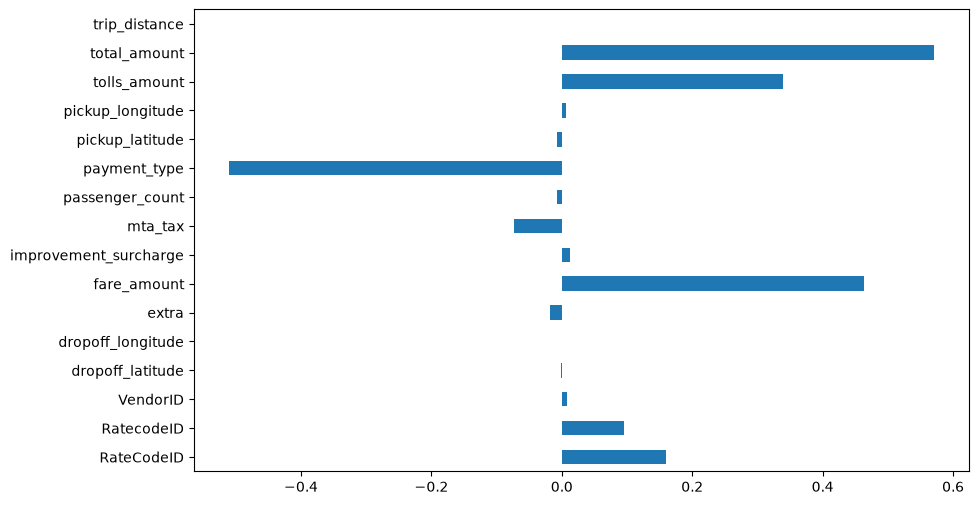

In [5]:
correlation_values = raw_data.corr(numeric_only=True)['tip_amount'].drop('tip_amount')
correlation_values.plot(kind='barh', figsize=(10, 6))

<div id="dataset_preprocessing">
    <h2>Dataset Preprocessing</h2>
</div>


We will now prepare the data for training by applying normalization to the input features.


In [7]:
raw_data.shape

(1446517, 20)

In [8]:
raw_data.dtypes

RateCodeID               float64
RatecodeID               float64
VendorID                   int64
dropoff_latitude         float64
dropoff_longitude        float64
extra                    float64
fare_amount              float64
improvement_surcharge    float64
mta_tax                  float64
passenger_count            int64
payment_type               int64
pickup_latitude          float64
pickup_longitude         float64
store_and_fwd_flag        object
tip_amount               float64
tolls_amount             float64
total_amount             float64
tpep_dropoff_datetime     object
tpep_pickup_datetime      object
trip_distance            float64
dtype: object

In [10]:
# target
y = raw_data[['tip_amount']].values.astype('float32')

# features
proc_data = raw_data.drop([
    'tip_amount',
    'tpep_pickup_datetime',
    'tpep_dropoff_datetime'
], axis=1)

# encode categorical column
proc_data['store_and_fwd_flag'] = (
    proc_data['store_and_fwd_flag']
    .map({'N': 0, 'Y': 1})
)

# fill missing values
proc_data = proc_data.fillna(proc_data.median(numeric_only=True))

# feature matrix
X = proc_data.values.astype('float32')

# normalize
X = normalize(X, axis=1, norm='l1', copy=False)

<div id="dataset_split">
    <h2>Dataset Train/Test Split</h2>
</div>


Now that the dataset is ready for building the classification models, we need to first divide the pre-processed dataset into a subset to be used for training the model (the train set) and a subset to be used for evaluating the quality of the model (the test set).


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

<div id="dt_sklearn">
    <h2>Build a Decision Tree Regressor model with Scikit-Learn</h2>
</div>


Regression Trees are implemented using `DecisionTreeRegressor`.

The important parameters of the model are:

`criterion`: The function used to measure error, we use 'squared_error'.

`max_depth` - The maximum depth the tree is allowed to take; we use 8.


In [12]:
# import the Decision Tree Regression Model from scikit-learn
from sklearn.tree import DecisionTreeRegressor

# for reproducible output across multiple function calls, set random_state to a given integer value
dt_reg = DecisionTreeRegressor(criterion = 'squared_error',
                               max_depth=8, 
                               random_state=35)

Now lets train our model using the `fit` method on the `DecisionTreeRegressor` object providing our training data


In [13]:
dt_reg.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=8, random_state=35)

<div id="dt_sklearn_snapml">
    <h2>Evaluate the Scikit-Learn and Snap ML Decision Tree Regressor Models</h2>
</div>


To evaluate our dataset we will use the `score` method of the `DecisionTreeRegressor` object providing our testing data, this number is the $R^2$ value which indicates the coefficient of determination. We will also evaluate the Mean Squared Error $(MSE)$ of the regression output with respect to the test set target values. High $R^2$ and low $MSE$ values are expected from a good regression model.


In [14]:
# run inference using the sklearn model
y_pred = dt_reg.predict(X_test)

# evaluate mean squared error on the test dataset
mse_score = mean_squared_error(y_test, y_pred)
print('MSE score : {0:.3f}'.format(mse_score))

r2_score = dt_reg.score(X_test,y_test)
print('R^2 score : {0:.3f}'.format(r2_score))

MSE score : 0.955
R^2 score : -0.000


## Questions
01. What if we change the max_depth to 12? How would the $MSE$ and $R^2$ be affected?

MSE is noted to be increased by increasing the max_depth of the tree. This may be because of the model having excessive parameters due to which it overfits to the training data, making the performance on the testing data poorer. Another important observation would be that the model gives a <b>negative</b> value of $R^2$. This again indicates that the prediction model created does a very poor job of predicting the values on a test set.


02. Identify the top 3 features with the most effect on the `tip_amount`.


In [16]:
correlation_values = (
    raw_data.corr(numeric_only=True)['tip_amount']
    .drop('tip_amount')
)

abs(correlation_values).sort_values(ascending=False)[:3]

total_amount    0.570169
payment_type    0.510207
fare_amount     0.463493
Name: tip_amount, dtype: float64

03. Since we identified 4 features which are not correlated with the target variable, try removing these variables from the input set and see the effect on the $MSE$ and $R^2$ value.


In [17]:
raw_data = raw_data.drop(['payment_type', 'VendorID', 'store_and_fwd_flag', 'improvement_surcharge'], axis=1)

The MSE and $R^2$ values does not change significantly, showing that there is minimal affect of these parameters on the final regression output.
